In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchaudio
from torch.utils.data import DataLoader
from transformers import ASTForAudioClassification, ASTFeatureExtractor
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score
from tqdm import tqdm

# Configuración de dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

c:\Users\Usuario\miniconda3\envs\gpu_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Usando dispositivo: cuda


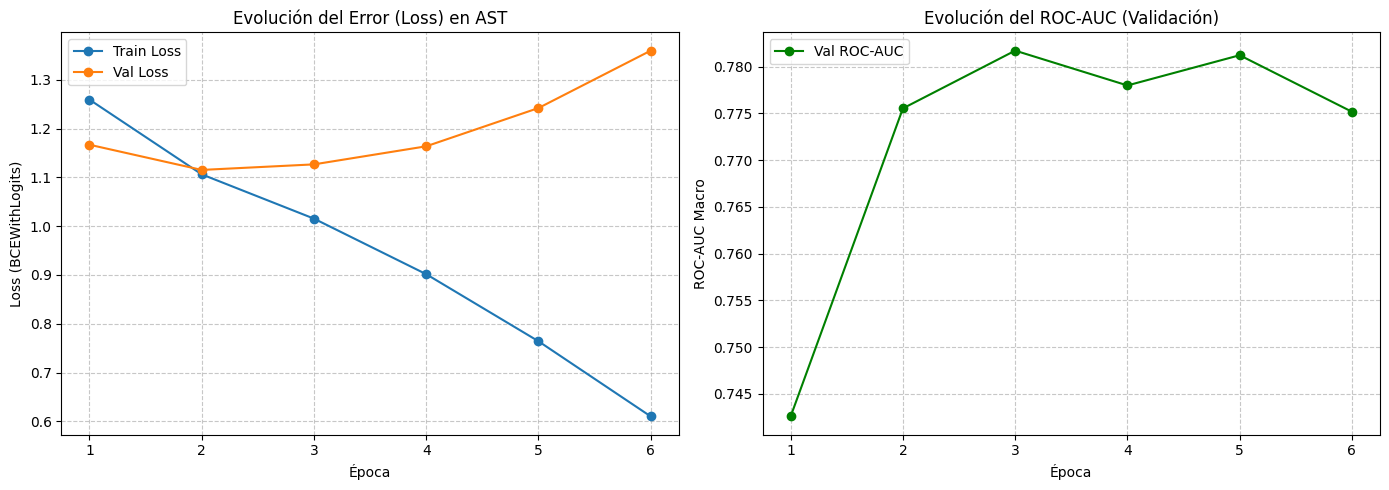

Mejor época: 3 con ROC-AUC de 0.7817


In [4]:
# Cargar el historial de entrenamiento
history_df = pd.read_csv("../src/history_ast.csv")

plt.figure(figsize=(14, 5))

# Gráfica de Loss
plt.subplot(1, 2, 1)
plt.plot(history_df['epoch'], history_df['train_loss'], label='Train Loss', marker='o')
plt.plot(history_df['epoch'], history_df['val_loss'], label='Val Loss', marker='o')
plt.title('Evolución del Error (Loss) en AST')
plt.xlabel('Época')
plt.ylabel('Loss (BCEWithLogits)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Gráfica de ROC-AUC
plt.subplot(1, 2, 2)
plt.plot(history_df['epoch'], history_df['val_auc'], label='Val ROC-AUC', color='green', marker='o')
plt.title('Evolución del ROC-AUC (Validación)')
plt.xlabel('Época')
plt.ylabel('ROC-AUC Macro')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

best_epoch = history_df.loc[history_df['val_auc'].idxmax()]
print(f"Mejor época: {int(best_epoch['epoch'])} con ROC-AUC de {best_epoch['val_auc']:.4f}")

In [ ]:
# CELDA 3: Carga del Modelo AST y Preparación de Datos (Split-0 Oficial)
# ─────────────────────────────────────────────────────────────────────────
import sys, os, numpy as np
sys.path.append(os.path.abspath("../src"))

from pathlib import Path
from dataset import MTGJamendoDataset, load_split_tsv
from audio_utils import AudioPreprocessor
from torch.utils.data import DataLoader

PROJECT_ROOT = Path.cwd().parent
AUDIO_DIR    = PROJECT_ROOT / "data" / "audio"
SRC_DIR      = PROJECT_ROOT / "src"

SPLIT_DIR = PROJECT_ROOT / "mtg-jamendo-dataset" / "data" / "splits" / "split-0"
TRAIN_TSV = SPLIT_DIR / "autotagging_moodtheme-train.tsv"
VAL_TSV   = SPLIT_DIR / "autotagging_moodtheme-validation.tsv"
TEST_TSV  = SPLIT_DIR / "autotagging_moodtheme-test.tsv"

# ── PROTOCOLO SAGRADO: interruptor de split de evaluación ──────────────────────
# Durante el desarrollo siempre se evalúa en VALIDACIÓN (split libre de Artist Effect).
# Cambiar a "test" ÚNICAMENTE para producir los resultados finales de la memoria TFG.
# El conjunto de test NO debe tocarse hasta que el sistema esté completamente cerrado.
EVAL_SPLIT = "val"   # ← cambiar a "test" solo para el reporte final
TSV_MAP    = {"val": VAL_TSV, "test": TEST_TSV}
EVAL_TSV   = TSV_MAP[EVAL_SPLIT]
print(f"Split de evaluación activo: '{EVAL_SPLIT}' → {EVAL_TSV.name}")

# Vocabulario derivado EXCLUSIVAMENTE del split de train
df_train = load_split_tsv(TRAIN_TSV)
etiquetas_jamendo = sorted(set(tag for tags in df_train['tags'] for tag in tags if tag.strip()))
NUM_CLASSES = len(etiquetas_jamendo)
print(f"Vocabulario (derivado de train): {NUM_CLASSES} etiquetas únicas")

# Cargar el split de evaluación seleccionado
df_eval = load_split_tsv(EVAL_TSV)
print(f"Canciones en el split '{EVAL_SPLIT}': {len(df_eval)}")

# AST trabaja a 16kHz (importante: distinto de PANNs que usa 32kHz)
preprocesador = AudioPreprocessor(target_sr=16000)
eval_ds     = MTGJamendoDataset(df_eval, AUDIO_DIR, preprocesador, etiquetas_jamendo, return_raw=True)
eval_loader = DataLoader(eval_ds, batch_size=2, shuffle=False, num_workers=4, pin_memory=True)

# Cargar feature extractor y modelo AST con los pesos fine-tuned
model_id = "MIT/ast-finetuned-audioset-10-10-0.4593"
feature_extractor = ASTFeatureExtractor.from_pretrained(model_id)

model = ASTForAudioClassification.from_pretrained(
    model_id,
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)
model.load_state_dict(torch.load(SRC_DIR / "best_ast_model.pth", map_location=device))
model.to(device)
model.eval()
print("Modelo AST cargado correctamente.")

In [ ]:
# CELDA 4: Inferencia AST sobre el split de evaluación
# ─────────────────────────────────────────────────────────────────────────────
# El feature_extractor transforma la onda cruda en fbank mel-filterbank patches
# que espera el Transformer. Replica exactamente el pipeline de train_ast.py.

all_preds  = []
all_labels = []

print(f"Iniciando inferencia sobre '{EVAL_SPLIT}'...")
with torch.no_grad():
    for x_raw, labels in tqdm(eval_loader, desc=f"Inferencia AST [{EVAL_SPLIT.upper()}]"):
        # x_raw: (batch, 480000) — audio crudo a 16kHz, 30 segundos
        inputs = feature_extractor(
            x_raw.numpy(), sampling_rate=16000, return_tensors="pt"
        )
        input_values = inputs.input_values.to(device)

        with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
            outputs = model(input_values)

        probs = torch.sigmoid(outputs.logits).cpu().float().numpy()
        all_preds.append(probs)
        all_labels.append(labels.numpy())

y_pred_probs = np.vstack(all_preds)
y_true       = np.vstack(all_labels)
print(f"Inferencia completada. y_true {y_true.shape} | y_pred {y_pred_probs.shape}")

In [ ]:
# CELDA 5: Métricas Completas — ROC-AUC, PR-AUC y F1 con Umbral Óptimo por Clase
# ──────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from scipy.stats import spearmanr

valid_cols = [i for i in range(y_true.shape[1]) if len(np.unique(y_true[:, i])) > 1]
print(f"Clases evaluables: {len(valid_cols)}/59")

# ── 1. Métricas independientes del umbral ──
roc_auc_macro = roc_auc_score(y_true[:, valid_cols], y_pred_probs[:, valid_cols], average='macro')
roc_auc_micro = roc_auc_score(y_true[:, valid_cols], y_pred_probs[:, valid_cols], average='micro')
pr_auc_macro  = average_precision_score(y_true[:, valid_cols], y_pred_probs[:, valid_cols], average='macro')
pr_auc_micro  = average_precision_score(y_true[:, valid_cols], y_pred_probs[:, valid_cols], average='micro')

# ── 2. Umbral óptimo por clase para F1 ──
print("\nOptimizando umbrales por clase...")
best_thresholds = np.full(y_true.shape[1], 0.5)
for c in valid_cols:
    best_f1, best_th = 0.0, 0.5
    for th in np.arange(0.05, 0.95, 0.05):
        preds_bin = (y_pred_probs[:, c] >= th).astype(int)
        score = f1_score(y_true[:, c], preds_bin, zero_division=0)
        if score > best_f1:
            best_f1, best_th = score, th
    best_thresholds[c] = best_th

y_pred_bin = (y_pred_probs >= best_thresholds).astype(int)
f1_macro   = f1_score(y_true, y_pred_bin, average='macro', zero_division=0)
f1_micro   = f1_score(y_true, y_pred_bin, average='micro', zero_division=0)

# ── 3. Tabla de resultados ──
print("\n╔══════════════════════════════════════════════════╗")
print("║         MÉTRICAS FINALES — AST Transformer        ║")
print("╠══════════════════════════════════════════════════╣")
print(f"║  ROC-AUC Macro:   {roc_auc_macro:.4f}                        ║")
print(f"║  ROC-AUC Micro:   {roc_auc_micro:.4f}                        ║")
print(f"║  PR-AUC  Macro:   {pr_auc_macro:.4f}                        ║")
print(f"║  PR-AUC  Micro:   {pr_auc_micro:.4f}                        ║")
print(f"║  F1-Score Macro:  {f1_macro:.4f} (umbral óptimo/clase) ║")
print(f"║  F1-Score Micro:  {f1_micro:.4f} (umbral óptimo/clase) ║")
print("╠══════════════════════════════════════════════════╣")
print(f"║  Baseline VGG-ish (MediaEval 2021): ROC-AUC=0.725 ║")
print(f"║  Δ vs Baseline:  {roc_auc_macro - 0.725:+.4f}                       ║")
print("╚══════════════════════════════════════════════════╝")

# ── 4. Top/Bottom 10 por ROC-AUC ──
auc_list = [{'Etiqueta': etiquetas_jamendo[i],
             'ROC-AUC': roc_auc_score(y_true[:, i], y_pred_probs[:, i]),
             'Soporte': int(y_true[:, i].sum())}
            for i in valid_cols]
df_auc = pd.DataFrame(auc_list).sort_values('ROC-AUC', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=df_auc.head(10), x='ROC-AUC', y='Etiqueta', palette='Greens_r', ax=ax1)
ax1.set_title('Top 10 Mejor Predichas (ROC-AUC)', fontweight='bold')
ax1.set_xlim(0.5, 1.0)

sns.barplot(data=df_auc.tail(10).sort_values('ROC-AUC'), x='ROC-AUC', y='Etiqueta', palette='Reds_r', ax=ax2)
ax2.set_title('Top 10 Peor Predichas (ROC-AUC)', fontweight='bold')
ax2.set_xlim(0.4, 0.95)
plt.tight_layout()
plt.savefig("ast_emotions_breakdown.png", dpi=300, bbox_inches='tight')
plt.show()

# ── 5. Soporte vs AUC ──
sop = y_true.sum(axis=0)[[i for i in valid_cols]]
auc = [roc_auc_score(y_true[:, i], y_pred_probs[:, i]) for i in valid_cols]
corr, pval = spearmanr(sop, auc)
print(f"\nCorrelación Spearman (Soporte ↔ AUC): ρ={corr:.3f}  p={pval:.4f}")

# Guardar para tabla comparativa global
np.save(SRC_DIR / "ast_y_true.npy",  y_true)
np.save(SRC_DIR / "ast_y_score.npy", y_pred_probs)
print("Resultados guardados en /src/ para la tabla comparativa global.")